In [375]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
print("Libraries imported successfully")

Libraries imported successfully


In [376]:
# Load the dataset
# Make sure your dataset.csv file is in the main project folder
df = pd.read_csv('../food_waste_prediction_dataset_1000_rows.csv')  # ../ goes up one level from notebook folder

# Display first few rows
print("First 5 rows of the dataset:")
print()
df.head()

First 5 rows of the dataset:



,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
0,Thursday,0,Cloudy,572,352,361,512
1,Sunday,0,Rainy,486,512,509,385
2,Wednesday,0,Sunny,516,385,390,460
3,Sunday,0,Rainy,462,460,480,337
4,Thursday,0,Cloudy,402,337,327,316


In [377]:
# Dataset dimensions
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Column data types
print("\nColumn Data Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (1000, 7)
Rows: 1000, Columns: 7

Column Data Types:
Day_of_Week                 object
Festival                     int64
Weather                     object
Expected_Customers           int64
Previous_Day_Consumption     int64
Previous_Week_Same_Day       int64
Meals_Consumed               int64
dtype: object

Basic Statistics:


,Festival,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.103000,474.430000,396.360000,398.821000,396.483000
std,0.304111,72.490012,72.968917,72.123344,72.997729
min,0.000000,350.000000,240.000000,300.000000,240.000000
25%,0.000000,412.000000,337.000000,337.000000,337.000000
50%,0.000000,474.000000,393.000000,392.500000,393.000000
75%,0.000000,535.250000,450.000000,450.250000,450.250000
max,1.000000,600.000000,606.000000,660.000000,606.000000


In [378]:
# Check missing values
print("Missing Values in each column:")
print(df.isnull().sum())

# Check for any other issues
print("\nDataset Info:")
df.info()

Missing Values in each column:
Day_of_Week                 0
Festival                    0
Weather                     0
Expected_Customers          0
Previous_Day_Consumption    0
Previous_Week_Same_Day      0
Meals_Consumed              0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Day_of_Week               1000 non-null   object
 1   Festival                  1000 non-null   int64 
 2   Weather                   1000 non-null   object
 3   Expected_Customers        1000 non-null   int64 
 4   Previous_Day_Consumption  1000 non-null   int64 
 5   Previous_Week_Same_Day    1000 non-null   int64 
 6   Meals_Consumed            1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


In [379]:
# Let's understand our categorical data first
print("\nUnique values in Day_of_Week:")
print(df['Day_of_Week'].unique())

print("\nUnique values in Weather:")
print(df['Weather'].unique())

print("\nUnique values in Festival:")
print(df['Festival'].unique())


Unique values in Day_of_Week:
['Thursday' 'Sunday' 'Wednesday' 'Tuesday' 'Monday' 'Saturday' 'Friday']

Unique values in Weather:
['Cloudy' 'Rainy' 'Sunny' 'Stormy']

Unique values in Festival:
[0 1]


In [380]:
# Create a copy of the dataframe for preprocessing
df_encoded = df.copy()

# One-Hot Encode Day_of_Week (since it's nominal - no order)
day_dummies = pd.get_dummies(df_encoded['Day_of_Week'], prefix='Day')
df_encoded = pd.concat([df_encoded, day_dummies], axis=1)

# Drop the original Day_of_Week column
df_encoded.drop('Day_of_Week', axis=1, inplace=True)

print("After One-Hot Encoding Day_of_Week:")
print(f"New columns added: {list(day_dummies.columns)}")
print(f"New shape: {df_encoded.shape}")

After One-Hot Encoding Day_of_Week:
New columns added: ['Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']
New shape: (1000, 13)


In [381]:
# Weather has natural order in terms of severity
# Stormy > Rainy > Cloudy > Sunny (in terms of impact on food demand)

# Create a mapping dictionary
weather_mapping = {
    'Sunny': 1,
    'Cloudy': 2,
    'Rainy': 3,
    'Stormy': 4
}

# Apply mapping
df_encoded['Weather_Encoded'] = df['Weather'].map(weather_mapping)

# Drop original Weather column
df_encoded.drop('Weather', axis=1, inplace=True)

print("Weather encoding mapping:")
for weather, value in weather_mapping.items():
    print(f"{weather} -> {value}")

print("\nFirst few rows after weather encoding:")
df_encoded[['Weather_Encoded']].head()

Weather encoding mapping:
Sunny -> 1
Cloudy -> 2
Rainy -> 3
Stormy -> 4

First few rows after weather encoding:


,Weather_Encoded
0,2
1,3
2,1
3,3
4,2


In [382]:
# Check data types after encoding
print("Data types after encoding:\n")
print(df_encoded.dtypes)
print()

# Check for any remaining object columns
object_columns = df_encoded.select_dtypes(include=['object']).columns
if len(object_columns) == 0:
    print("All columns are now numeric! Ready for modeling.")
else:
    print(f"Still have object columns: {object_columns}")

Data types after encoding:

Festival                    int64
Expected_Customers          int64
Previous_Day_Consumption    int64
Previous_Week_Same_Day      int64
Meals_Consumed              int64
Day_Friday                   bool
Day_Monday                   bool
Day_Saturday                 bool
Day_Sunday                   bool
Day_Thursday                 bool
Day_Tuesday                  bool
Day_Wednesday                bool
Weather_Encoded             int64
dtype: object

All columns are now numeric! Ready for modeling.


In [383]:
# Display first few rows of final preprocessed data
print("First 5 rows of preprocessed data:")
df_encoded.head()

First 5 rows of preprocessed data:


,Festival,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Weather_Encoded
0,0,572,352,361,512,False,False,False,False,True,False,False,2
1,0,486,512,509,385,False,False,False,True,False,False,False,3
2,0,516,385,390,460,False,False,False,False,False,False,True,1
3,0,462,460,480,337,False,False,False,True,False,False,False,3
4,0,402,337,327,316,False,False,False,False,True,False,False,2


In [384]:
# Save preprocessed data (optional)
df_encoded.to_csv('../preprocessed_data.csv', index=False)
print("Preprocessed data saved as 'preprocessed_data.csv'")

Preprocessed data saved as 'preprocessed_data.csv'


In [385]:
# Quick verification
print("Original dataset shape:", df.shape)
print("Preprocessed dataset shape:", df_encoded.shape)
print("\nColumns in preprocessed data:")
for col in df_encoded.columns:
    print(f"   {col}")

Original dataset shape: (1000, 7)
Preprocessed dataset shape: (1000, 13)

Columns in preprocessed data:
   Festival
   Expected_Customers
   Previous_Day_Consumption
   Previous_Week_Same_Day
   Meals_Consumed
   Day_Friday
   Day_Monday
   Day_Saturday
   Day_Sunday
   Day_Thursday
   Day_Tuesday
   Day_Wednesday
   Weather_Encoded


In [386]:
# Set up beautiful visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
figsize = (12, 6)

print(" Visualization style set")

 Visualization style set


Statistics of Meals_Consumed:

count    1000.000000
mean      396.483000
std        72.997729
min       240.000000
25%       337.000000
50%       393.000000
75%       450.250000
max       606.000000
Name: Meals_Consumed, dtype: float64



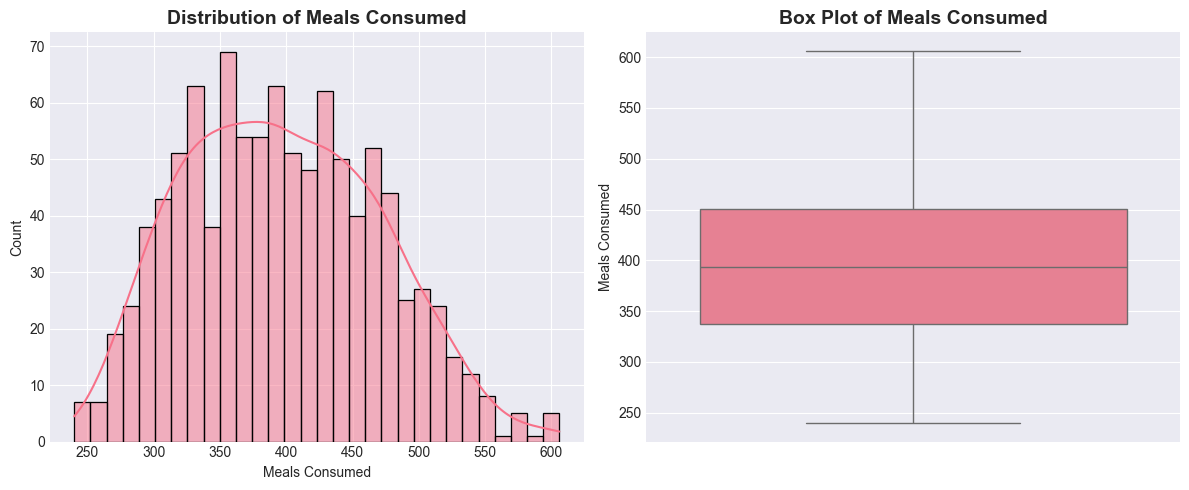

In [387]:
# Understand our target variable (Meals_Consumed)
print("Statistics of Meals_Consumed:")
print()
print(df_encoded['Meals_Consumed'].describe())
print()

# Distribution of Meals_Consumed
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_encoded['Meals_Consumed'], bins=30, kde=True)
plt.title('Distribution of Meals Consumed', fontsize=14, fontweight='bold')
plt.xlabel('Meals Consumed')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_encoded['Meals_Consumed'])
plt.title('Box Plot of Meals Consumed', fontsize=14, fontweight='bold')
plt.ylabel('Meals Consumed')

plt.tight_layout()
plt.show()

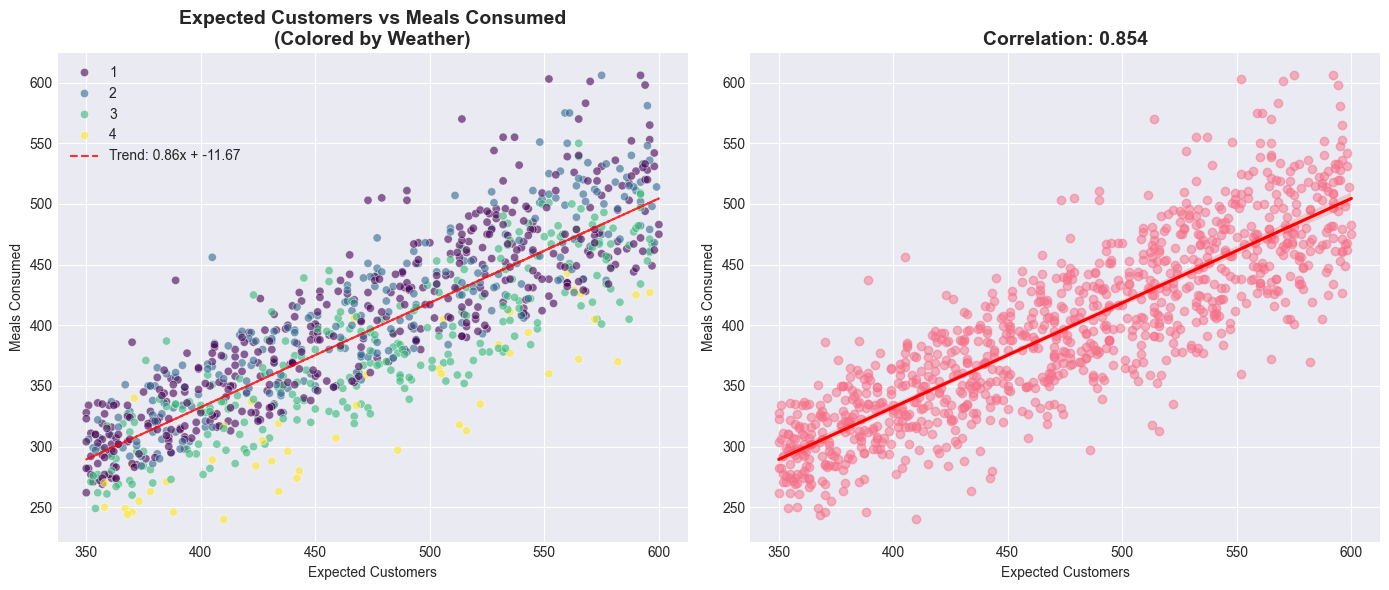

Correlation between Expected Customers and Meals Consumed: 0.854


In [388]:
# This is the most important relationship
plt.figure(figsize=(14, 6))

# Scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_encoded, x='Expected_Customers', y='Meals_Consumed', 
                hue='Weather_Encoded', palette='viridis', alpha=0.6)
plt.title('Expected Customers vs Meals Consumed\n(Colored by Weather)', fontsize=14, fontweight='bold')
plt.xlabel('Expected Customers')
plt.ylabel('Meals Consumed')

# Add trend line
z = np.polyfit(df_encoded['Expected_Customers'], df_encoded['Meals_Consumed'], 1)
p = np.poly1d(z)
plt.plot(df_encoded['Expected_Customers'], p(df_encoded['Expected_Customers']), 
         "r--", alpha=0.8, label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')
plt.legend()

# Correlation
plt.subplot(1, 2, 2)
correlation = df_encoded['Expected_Customers'].corr(df_encoded['Meals_Consumed'])
sns.regplot(data=df_encoded, x='Expected_Customers', y='Meals_Consumed', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation: {correlation:.3f}', fontsize=14, fontweight='bold')
plt.xlabel('Expected Customers')
plt.ylabel('Meals Consumed')

plt.tight_layout()
plt.show()

print(f"Correlation between Expected Customers and Meals Consumed: {correlation:.3f}")

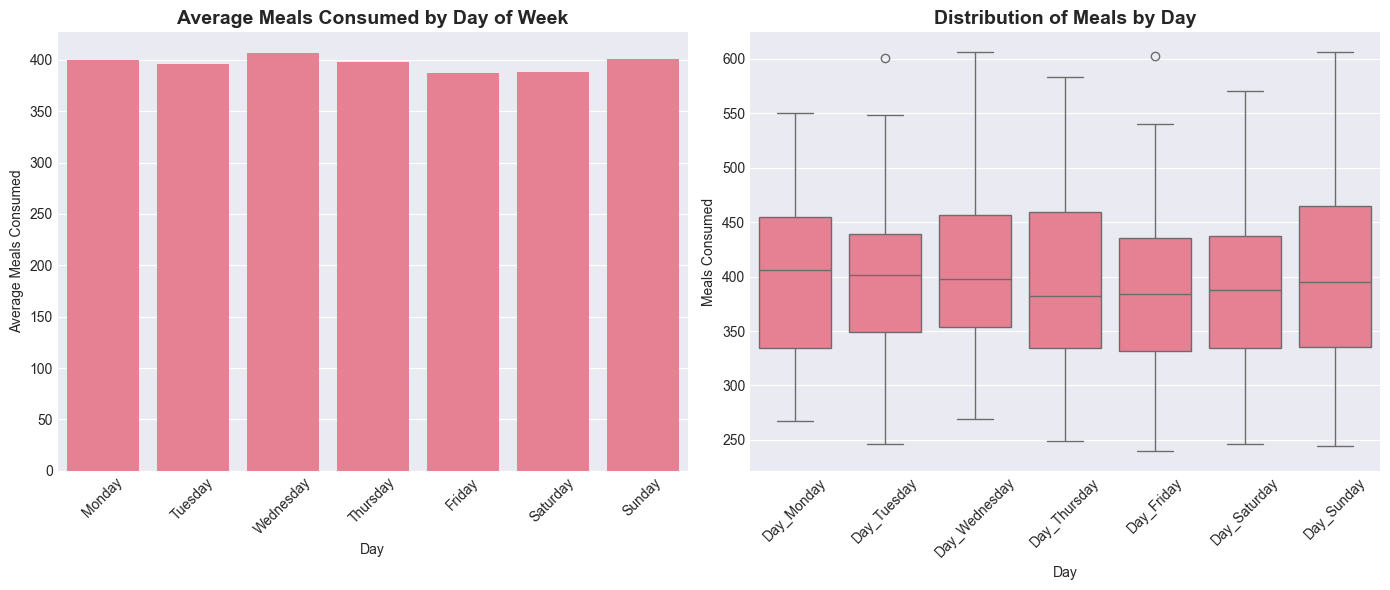

Average Meals by Day:
  Monday: 399.9
  Tuesday: 396.1
  Wednesday: 406.5
  Thursday: 397.7
  Friday: 387.1
  Saturday: 388.2
  Sunday: 401.4


In [389]:
# Create a dataframe for day-wise analysis
day_columns = ['Day_Monday', 'Day_Tuesday', 'Day_Wednesday', 'Day_Thursday', 
               'Day_Friday', 'Day_Saturday', 'Day_Sunday']

# Calculate average meals for each day
day_avg_meals = {}
for day in day_columns:
    day_data = df_encoded[df_encoded[day] == True]['Meals_Consumed']
    day_avg_meals[day.replace('Day_', '')] = day_data.mean()

# Convert to dataframe for plotting
day_avg_df = pd.DataFrame(list(day_avg_meals.items()), columns=['Day', 'Average Meals'])

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=day_avg_df, x='Day', y='Average Meals', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Average Meals Consumed by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Meals Consumed')
plt.xticks(rotation=45)

# Box plot for distribution
plt.subplot(1, 2, 2)
melted_data = pd.melt(df_encoded, id_vars=['Meals_Consumed'], value_vars=day_columns)
melted_data = melted_data[melted_data['value'] == True]
sns.boxplot(data=melted_data, x='variable', y='Meals_Consumed')
plt.title('Distribution of Meals by Day', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Meals Consumed')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Average Meals by Day:")
for day, avg in day_avg_meals.items():
    print(f"  {day}: {avg:.1f}")

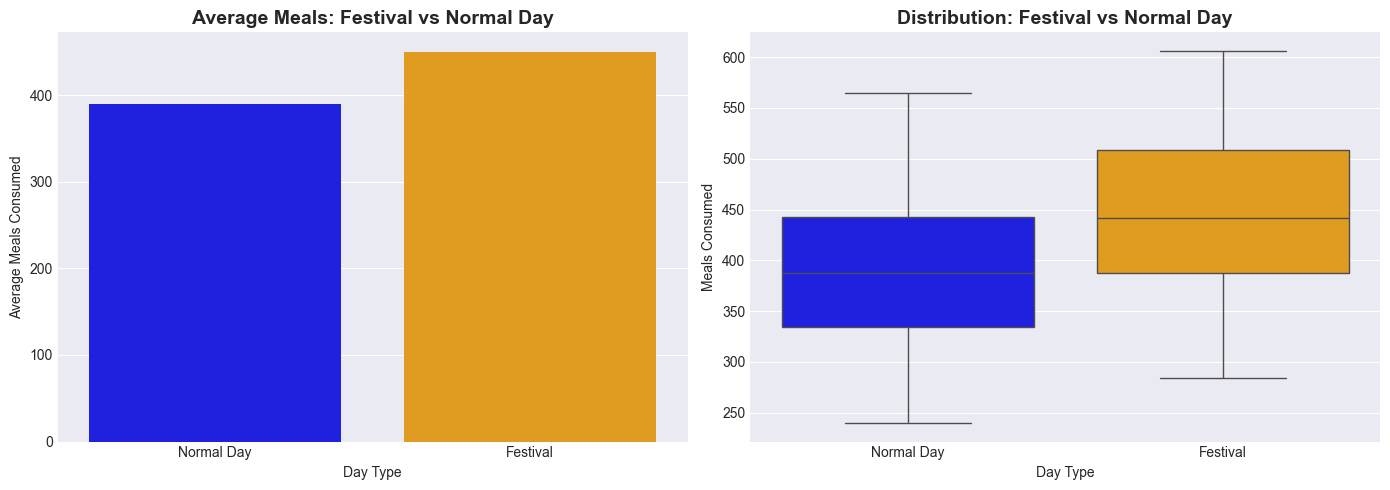

Festival Impact Statistics:
                  mean        std  count
Normal Day  390.323300  69.319075    897
Festival    450.126214  82.099495    103

Festival increases demand by: 59.8 meals on average


In [390]:
plt.figure(figsize=(14, 5))

# Bar plot for festival impact
plt.subplot(1, 2, 1)
festival_avg = df_encoded.groupby('Festival')['Meals_Consumed'].mean().reset_index()
festival_avg['Festival'] = festival_avg['Festival'].map({0: 'Normal Day', 1: 'Festival'})

sns.barplot(data=festival_avg, x='Festival', y='Meals_Consumed', palette=['blue', 'orange'])
plt.title('Average Meals: Festival vs Normal Day', fontsize=14, fontweight='bold')
plt.xlabel('Day Type')
plt.ylabel('Average Meals Consumed')

# Box plot comparison
plt.subplot(1, 2, 2)
df_encoded['Festival_Label'] = df_encoded['Festival'].map({0: 'Normal Day', 1: 'Festival'})
sns.boxplot(data=df_encoded, x='Festival_Label', y='Meals_Consumed', palette=['blue', 'orange'])
plt.title('Distribution: Festival vs Normal Day', fontsize=14, fontweight='bold')
plt.xlabel('Day Type')
plt.ylabel('Meals Consumed')

plt.tight_layout()
plt.show()

# Statistical summary
festival_stats = df_encoded.groupby('Festival')['Meals_Consumed'].agg(['mean', 'std', 'count'])
festival_stats.index = ['Normal Day', 'Festival']
print("Festival Impact Statistics:")
print(festival_stats)
print(f"\nFestival increases demand by: {festival_stats.loc['Festival', 'mean'] - festival_stats.loc['Normal Day', 'mean']:.1f} meals on average")

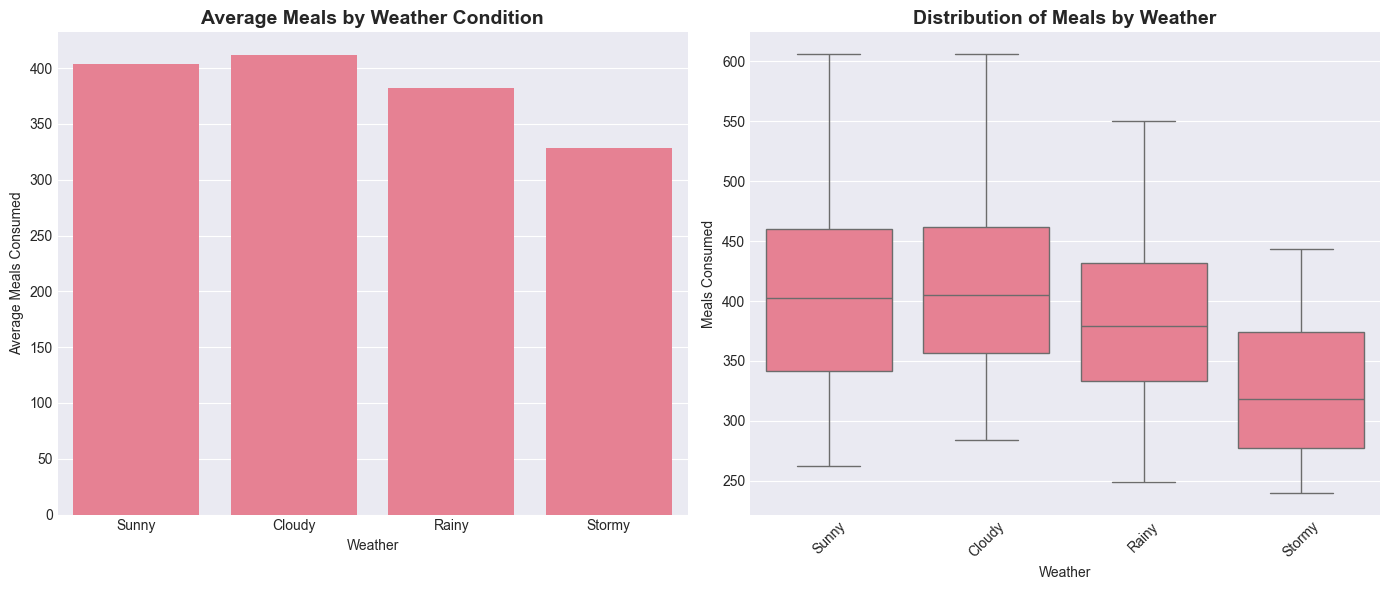

Weather Impact Statistics:
                     mean        std  count
Weather_Label                              
Cloudy         411.471774  71.122230    248
Rainy          382.441065  64.643321    263
Stormy         328.340426  61.121147     47
Sunny          403.674208  74.665833    442


In [391]:
plt.figure(figsize=(14, 6))

# Reverse mapping for weather
weather_reverse = {1: 'Sunny', 2: 'Cloudy', 3: 'Rainy', 4: 'Stormy'}
df_encoded['Weather_Label'] = df_encoded['Weather_Encoded'].map(weather_reverse)

# Bar plot
plt.subplot(1, 2, 1)
weather_avg = df_encoded.groupby('Weather_Label')['Meals_Consumed'].mean().reset_index()
weather_order = ['Sunny', 'Cloudy', 'Rainy', 'Stormy']
sns.barplot(data=weather_avg, x='Weather_Label', y='Meals_Consumed', order=weather_order)
plt.title('Average Meals by Weather Condition', fontsize=14, fontweight='bold')
plt.xlabel('Weather')
plt.ylabel('Average Meals Consumed')

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df_encoded, x='Weather_Label', y='Meals_Consumed', order=weather_order)
plt.title('Distribution of Meals by Weather', fontsize=14, fontweight='bold')
plt.xlabel('Weather')
plt.ylabel('Meals Consumed')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Weather Impact Statistics:")
weather_stats = df_encoded.groupby('Weather_Label')['Meals_Consumed'].agg(['mean', 'std', 'count'])
print(weather_stats)

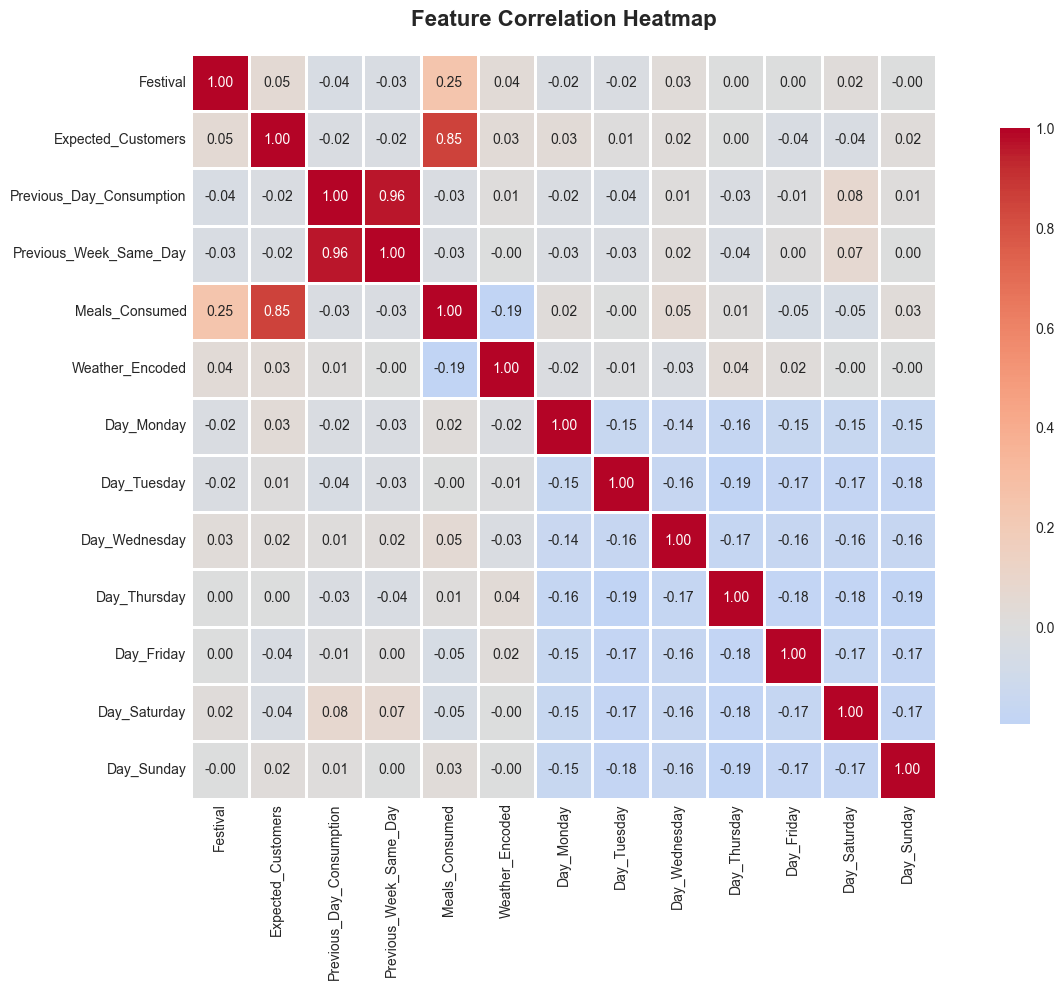


Features most correlated with Meals_Consumed:

Meals_Consumed              1.000000
Expected_Customers          0.854324
Festival                    0.249141
Day_Wednesday               0.052765
Day_Sunday                  0.028022
Day_Monday                  0.017041
Day_Thursday                0.007543
Day_Tuesday                -0.002347
Previous_Week_Same_Day     -0.025672
Previous_Day_Consumption   -0.029960
Day_Saturday               -0.046596
Day_Friday                 -0.053097
Weather_Encoded            -0.193350
Name: Meals_Consumed, dtype: float64


In [392]:
# Select numerical columns for correlation
numerical_cols = ['Festival', 'Expected_Customers', 'Previous_Day_Consumption', 
                  'Previous_Week_Same_Day', 'Meals_Consumed', 'Weather_Encoded']

# Add day columns to correlation
all_cols_for_corr = numerical_cols + day_columns

plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded[all_cols_for_corr].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find top features correlated with Meals_Consumed
target_corr = correlation_matrix['Meals_Consumed'].sort_values(ascending=False)
print("\nFeatures most correlated with Meals_Consumed:\n")
print(target_corr)

In [393]:
print()
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print()

# Insight 1: Expected Customers impact
cust_corr = df_encoded['Expected_Customers'].corr(df_encoded['Meals_Consumed'])
print(f"\n1. Expected Customers Correlation: {cust_corr:.3f}")
print("    This is the strongest predictor of food demand")

# Insight 2: Best and worst days
day_means = {day.replace('Day_', ''): df_encoded[df_encoded[day] == True]['Meals_Consumed'].mean() 
             for day in day_columns}
best_day = max(day_means, key=day_means.get)
worst_day = min(day_means, key=day_means.get)
print(f"\n2. Day-wise Demand:")
print(f"   Highest demand: {best_day} ({day_means[best_day]:.1f} meals)")
print(f"   Lowest demand: {worst_day} ({day_means[worst_day]:.1f} meals)")

# Insight 3: Festival impact
fest_impact = festival_stats.loc['Festival', 'mean'] - festival_stats.loc['Normal Day', 'mean']
print(f"\n3. Festival Impact:")
print(f"   Festivals increase demand by {fest_impact:.1f} meals on average")

# Insight 4: Weather impact
print(f"\n4. Weather Impact:")
for weather in weather_order:
    avg = weather_stats.loc[weather, 'mean']
    print(f"    {weather}: {avg:.1f} meals")



KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS


1. Expected Customers Correlation: 0.854
    This is the strongest predictor of food demand

2. Day-wise Demand:
   Highest demand: Wednesday (406.5 meals)
   Lowest demand: Friday (387.1 meals)

3. Festival Impact:
   Festivals increase demand by 59.8 meals on average

4. Weather Impact:
    Sunny: 403.7 meals
    Cloudy: 411.5 meals
    Rainy: 382.4 meals
    Stormy: 328.3 meals


In [394]:
# Start with our encoded dataframe
df_featured = df_encoded.copy()

print()
print("FEATURE ENGINEERING : Creating Powerful New Features")
print()
print(f"Original features: {df_featured.shape[1]}")


FEATURE ENGINEERING : Creating Powerful New Features

Original features: 15



FEATURE 1: Weekend Indicator

               mean  count
Weekday  397.147309    706
Weekend  394.887755    294

Weekend vs Weekday difference: -2.3 meals


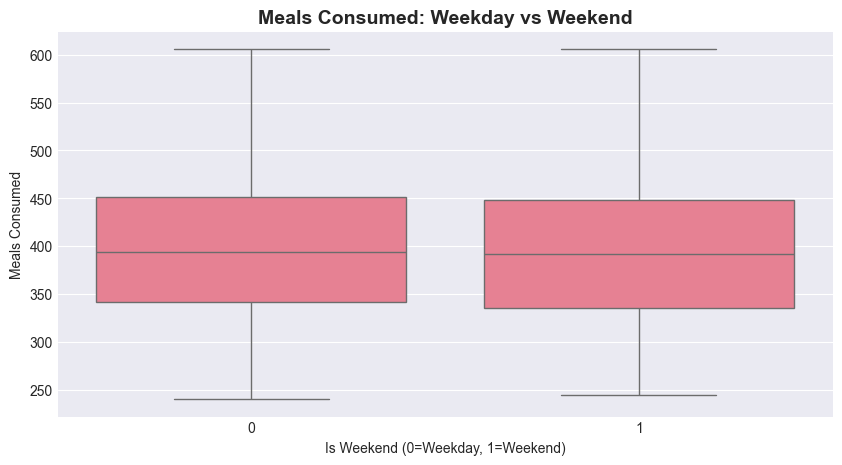

In [395]:
# Weekend Indicator (Saturday and Sunday are weekends)
df_featured['Is_Weekend'] = (df_featured['Day_Saturday'] | df_featured['Day_Sunday']).astype(int)

# Analyze weekend impact
weekend_stats = df_featured.groupby('Is_Weekend')['Meals_Consumed'].agg(['mean', 'count'])
weekend_stats.index = ['Weekday', 'Weekend']

print("\nFEATURE 1: Weekend Indicator")
print()
print(weekend_stats)
print(f"\nWeekend vs Weekday difference: {weekend_stats.loc['Weekend', 'mean'] - weekend_stats.loc['Weekday', 'mean']:.1f} meals")

# Visualize
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_featured, x='Is_Weekend', y='Meals_Consumed')
plt.title('Meals Consumed: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Is Weekend (0=Weekday, 1=Weekend)')
plt.ylabel('Meals Consumed')
plt.show()


FEATURE 2: Consumption Ratio of Meals/Customers

Mean ratio: 0.835
Min ratio: 0.585
Max ratio: 1.126


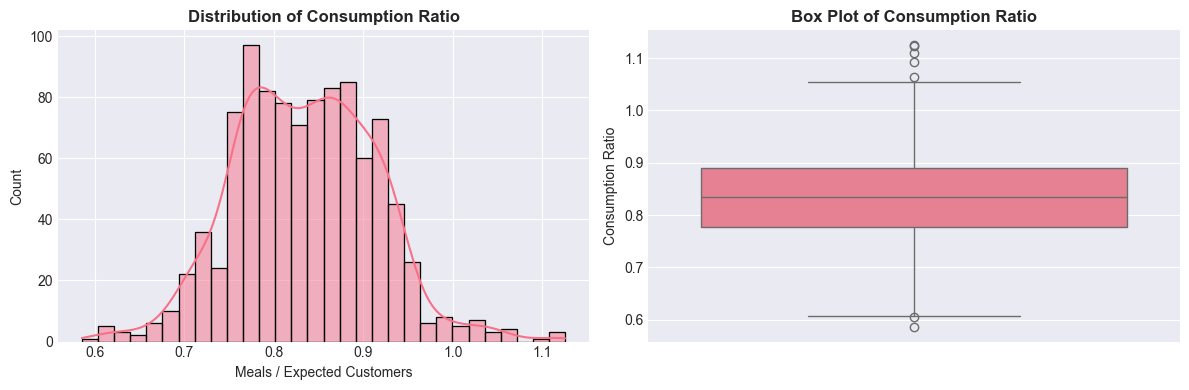

In [396]:
# Ratio of actual meals to expected customers
# This shows what percentage of expected customers actually showed up
df_featured['Consumption_Ratio'] = df_featured['Meals_Consumed'] / df_featured['Expected_Customers']

print("\nFEATURE 2: Consumption Ratio of Meals/Customers")
print()
print(f"Mean ratio: {df_featured['Consumption_Ratio'].mean():.3f}")
print(f"Min ratio: {df_featured['Consumption_Ratio'].min():.3f}")
print(f"Max ratio: {df_featured['Consumption_Ratio'].max():.3f}")

# Distribution of ratio
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_featured['Consumption_Ratio'], bins=30, kde=True)
plt.title('Distribution of Consumption Ratio', fontsize=12, fontweight='bold')
plt.xlabel('Meals / Expected Customers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_featured['Consumption_Ratio'])
plt.title('Box Plot of Consumption Ratio', fontsize=12, fontweight='bold')
plt.ylabel('Consumption Ratio')

plt.tight_layout()
plt.show()


FEATURE 3: Demand Trend vs Previous Week

Mean trend: -2.3
Min trend: -315.0
Max trend: 270.0


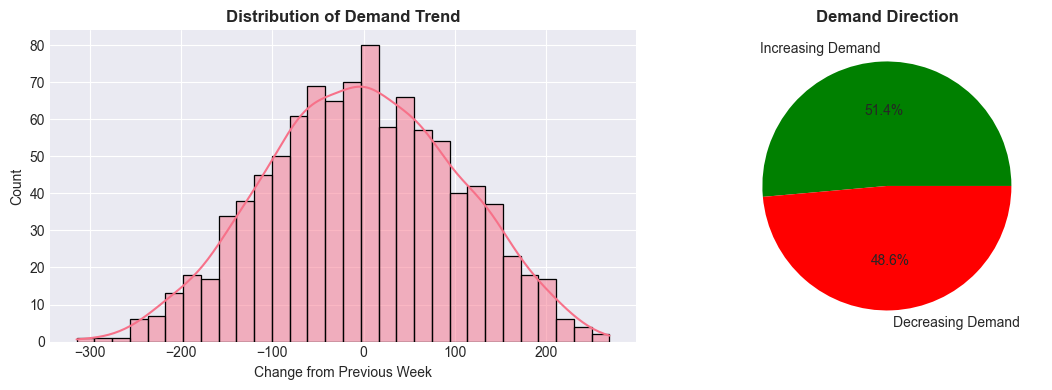

In [397]:
# How demand changed compared to same day last week
df_featured['Demand_Trend'] = df_featured['Meals_Consumed'] - df_featured['Previous_Week_Same_Day']

print("\nFEATURE 3: Demand Trend vs Previous Week")
print()
print(f"Mean trend: {df_featured['Demand_Trend'].mean():.1f}")
print(f"Min trend: {df_featured['Demand_Trend'].min():.1f}")
print(f"Max trend: {df_featured['Demand_Trend'].max():.1f}")

# Show trend distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_featured['Demand_Trend'], bins=30, kde=True)
plt.title('Distribution of Demand Trend', fontsize=12, fontweight='bold')
plt.xlabel('Change from Previous Week')

plt.subplot(1, 2, 2)
# Positive trend vs negative trend
trend_direction = (df_featured['Demand_Trend'] > 0).value_counts()
plt.pie(trend_direction.values, labels=['Increasing Demand', 'Decreasing Demand'], 
        autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Demand Direction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


FEATURE 4: Daily Momentum vs Previous Day

Mean momentum: 0.1
Min momentum: -301.0
Max momentum: 275.0


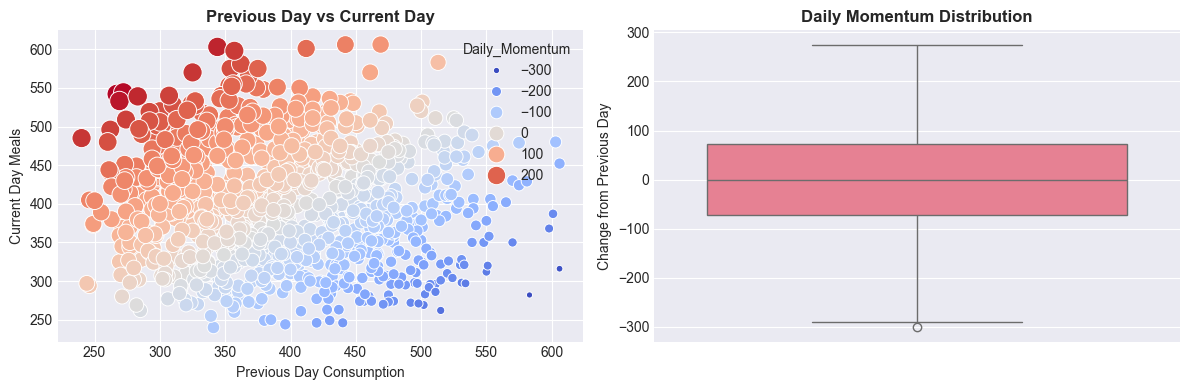

In [398]:
# How demand changed from previous day
df_featured['Daily_Momentum'] = df_featured['Meals_Consumed'] - df_featured['Previous_Day_Consumption']

print("\nFEATURE 4: Daily Momentum vs Previous Day")
print()
print(f"Mean momentum: {df_featured['Daily_Momentum'].mean():.1f}")
print(f"Min momentum: {df_featured['Daily_Momentum'].min():.1f}")
print(f"Max momentum: {df_featured['Daily_Momentum'].max():.1f}")

# Visualize momentum
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_featured, x='Previous_Day_Consumption', y='Meals_Consumed', 
                hue='Daily_Momentum', palette='coolwarm', size='Daily_Momentum', sizes=(20, 200))
plt.title('Previous Day vs Current Day', fontsize=12, fontweight='bold')
plt.xlabel('Previous Day Consumption')
plt.ylabel('Current Day Meals')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_featured['Daily_Momentum'])
plt.title('Daily Momentum Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Change from Previous Day')

plt.tight_layout()
plt.show()


FEATURE 5: Weather Festival Interaction

This feature captures combined effect of weather and festival

Average Meals by Weather-Festival combination:

         Normal Day    Festival
Sunny   396.072682  474.209302
Cloudy  404.806167  483.523810
Rainy   377.726087  415.303030
Stormy  324.853659  352.166667


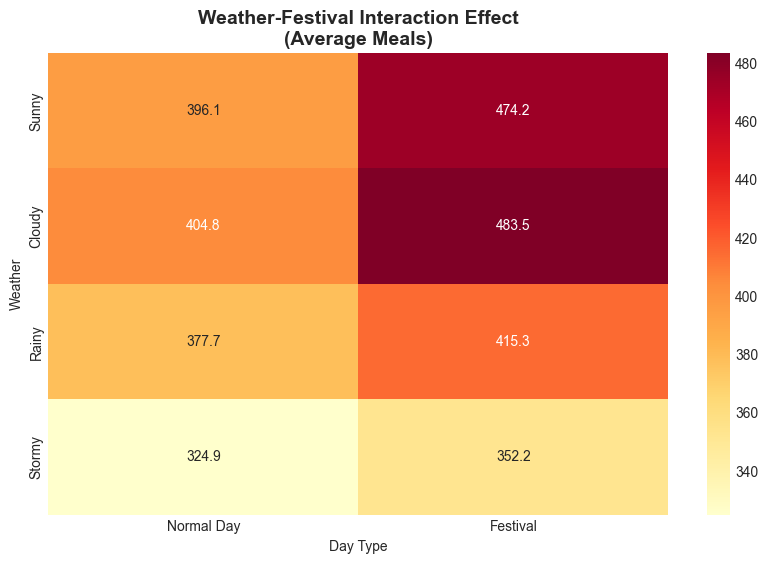

In [399]:
# Interaction between weather severity and festival
# Bad weather on festival might have different impact
df_featured['Weather_Festival'] = df_featured['Weather_Encoded'] * (df_featured['Festival'] + 1)

print("\nFEATURE 5: Weather Festival Interaction")
print()
print("This feature captures combined effect of weather and festival")
print("\nAverage Meals by Weather-Festival combination:")

# Show interaction effect
interaction_stats = df_featured.groupby(['Weather_Encoded', 'Festival'])['Meals_Consumed'].mean().unstack()
interaction_stats.index = [weather_reverse[i] for i in interaction_stats.index]
interaction_stats.columns = ['Normal Day', 'Festival']
print("\n", interaction_stats)

# Visualize interaction
plt.figure(figsize=(10, 6))
sns.heatmap(interaction_stats, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Weather-Festival Interaction Effect\n(Average Meals)', fontsize=14, fontweight='bold')
plt.xlabel('Day Type')
plt.ylabel('Weather')
plt.show()


FEATURE 6: Customer Level Categories
Customer Level Distribution:
Customer_Level
Low       336
Medium    332
High      332
Name: count, dtype: int64

Customer dummies shape: (1000, 3)
Customer dummies columns: ['Customer_Level_Low', 'Customer_Level_Medium', 'Customer_Level_High']

Verifying new columns were added:
Customer Level columns in dataframe: ['Customer_Level', 'Customer_Level_Low', 'Customer_Level_Medium', 'Customer_Level_High']

Average Meals by Customer Level:
                      mean  count
Customer_Level                   
Low             325.383929    336
Medium          395.527108    332
High            469.394578    332


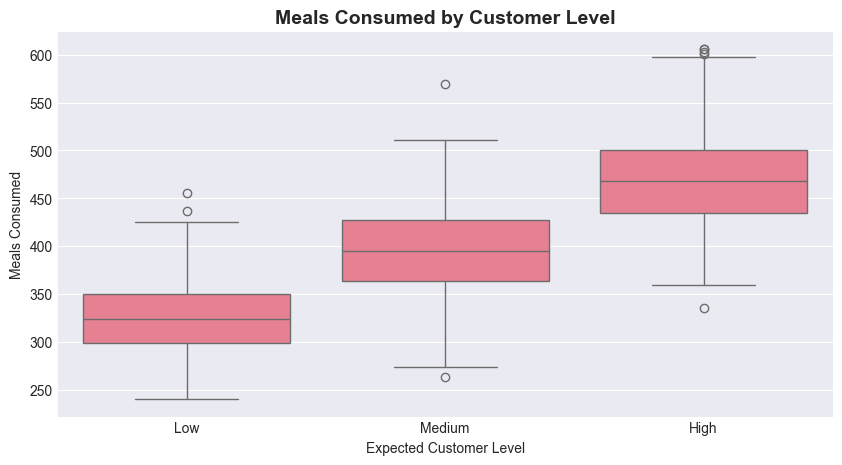

In [400]:
# Feature 6: Expected Capacity Utilization
print("\nFEATURE 6: Customer Level Categories")

# Create bins for expected customers (low/medium/high)
df_featured['Customer_Level'] = pd.cut(df_featured['Expected_Customers'], 
                                        bins=3, 
                                        labels=['Low', 'Medium', 'High'])

print("Customer Level Distribution:")
print(df_featured['Customer_Level'].value_counts())

# One-hot encode customer level
customer_dummies = pd.get_dummies(df_featured['Customer_Level'], prefix='Customer_Level')
print(f"\nCustomer dummies shape: {customer_dummies.shape}")
print(f"Customer dummies columns: {list(customer_dummies.columns)}")

# Concatenate the dummy columns to df_featured
df_featured = pd.concat([df_featured, customer_dummies], axis=1)

# Verify the columns were added
print("\nVerifying new columns were added:")
customer_level_cols = [col for col in df_featured.columns if 'Customer_Level' in col]
print(f"Customer Level columns in dataframe: {customer_level_cols}")

# Analyze by customer level
level_stats = df_featured.groupby('Customer_Level')['Meals_Consumed'].agg(['mean', 'count'])
print("\nAverage Meals by Customer Level:")
print(level_stats)

# Visualize
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_featured, x='Customer_Level', y='Meals_Consumed', 
            order=['Low', 'Medium', 'High'])
plt.title('Meals Consumed by Customer Level', fontsize=14, fontweight='bold')
plt.xlabel('Expected Customer Level')
plt.ylabel('Meals Consumed')
plt.show()

# Note: We'll keep Customer_Level for now, but we can drop it later if needed
# We're keeping it for analysis, but the dummy columns are what we'll use for modeling

In [401]:
# FIX DUPLICATE COLUMNS - Add this as a new cell after Cell 26
print()
print("FIXING DUPLICATE COLUMNS")


# Check for duplicate columns
duplicate_cols = df_featured.columns[df_featured.columns.duplicated()].unique()
print(f"Found {len(duplicate_cols)} duplicate columns: {list(duplicate_cols)}")

if len(duplicate_cols) > 0:
    # Remove duplicate columns (keep first occurrence)
    df_featured = df_featured.loc[:, ~df_featured.columns.duplicated()]
    print(f"Removed duplicates. New shape: {df_featured.shape}")
    
    # Verify no duplicates remain
    duplicate_cols_after = df_featured.columns[df_featured.columns.duplicated()].unique()
    if len(duplicate_cols_after) == 0:
        print("No duplicate columns remaining!")
else:
    print("No duplicate columns found!")

# Now check all columns are unique
print(f"\nFinal columns ({len(df_featured.columns)}):")
for i, col in enumerate(sorted(df_featured.columns), 1):
    print(f"{i:3d}. {col}")


FIXING DUPLICATE COLUMNS
Found 0 duplicate columns: []
No duplicate columns found!

Final columns (24):
  1. Consumption_Ratio
  2. Customer_Level
  3. Customer_Level_High
  4. Customer_Level_Low
  5. Customer_Level_Medium
  6. Daily_Momentum
  7. Day_Friday
  8. Day_Monday
  9. Day_Saturday
 10. Day_Sunday
 11. Day_Thursday
 12. Day_Tuesday
 13. Day_Wednesday
 14. Demand_Trend
 15. Expected_Customers
 16. Festival
 17. Festival_Label
 18. Is_Weekend
 19. Meals_Consumed
 20. Previous_Day_Consumption
 21. Previous_Week_Same_Day
 22. Weather_Encoded
 23. Weather_Festival
 24. Weather_Label


In [402]:
print()
print("SUMMARY OF ENGINEERED FEATURES")

# Get all customer level columns (now without duplicates)
customer_level_cols = [col for col in df_featured.columns if 'Customer_Level' in col and col != 'Customer_Level']
new_features = ['Is_Weekend', 'Consumption_Ratio', 'Demand_Trend', 
                'Daily_Momentum', 'Weather_Festival'] + customer_level_cols

print(f"\nCreated {len(new_features)} new features:")
for feature in new_features:
    print(f"   • {feature}")

print(f"\nOriginal feature count: {df_encoded.shape[1]}")
print(f"New feature count: {df_featured.shape[1]}")
print(f"Total features now: {df_featured.shape[1]}")

print("\nSample of new features (first 5 rows):")
# Check which columns actually exist
available_cols = ['Meals_Consumed'] + [f for f in new_features if f in df_featured.columns]
print(f"Displaying columns: {available_cols}")
df_featured[available_cols].head()


SUMMARY OF ENGINEERED FEATURES

Created 8 new features:
   • Is_Weekend
   • Consumption_Ratio
   • Demand_Trend
   • Daily_Momentum
   • Weather_Festival
   • Customer_Level_Low
   • Customer_Level_Medium
   • Customer_Level_High

Original feature count: 15
New feature count: 24
Total features now: 24

Sample of new features (first 5 rows):
Displaying columns: ['Meals_Consumed', 'Is_Weekend', 'Consumption_Ratio', 'Demand_Trend', 'Daily_Momentum', 'Weather_Festival', 'Customer_Level_Low', 'Customer_Level_Medium', 'Customer_Level_High']


,Meals_Consumed,Is_Weekend,Consumption_Ratio,Demand_Trend,Daily_Momentum,Weather_Festival,Customer_Level_Low,Customer_Level_Medium,Customer_Level_High
0,512,0,0.895105,151,160,2,False,False,True
1,385,1,0.792181,-124,-127,3,False,True,False
2,460,0,0.891473,70,75,1,False,True,False
3,337,1,0.729437,-143,-123,3,False,True,False
4,316,0,0.786070,-11,-21,2,True,False,False


In [403]:
# Verification Cell - Run this after fixing duplicates
print()
print("VERIFICATION OF ALL FEATURES")

# Check all columns in df_featured
print(f"\nTotal columns in df_featured: {df_featured.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(sorted(df_featured.columns), 1):
    print(f"{i:3d}. {col}")

# Specifically check for Customer_Level columns
customer_cols = [col for col in df_featured.columns if 'Customer_Level' in col and col != 'Customer_Level']
print(f"\nCustomer_Level columns found: {customer_cols}")

# Check if any expected columns are missing
expected_new_features = ['Is_Weekend', 'Consumption_Ratio', 'Demand_Trend', 
                         'Daily_Momentum', 'Weather_Festival']
missing_features = [f for f in expected_new_features if f not in df_featured.columns]

if missing_features:
    print(f"\nMissing features: {missing_features}")
else:
    print(f"\nAll expected features are present!")

# Data type check
print("\nData types of new features:")
for col in expected_new_features + customer_cols:
    if col in df_featured.columns:
        print(f"  {col}: {df_featured[col].dtype}")


VERIFICATION OF ALL FEATURES

Total columns in df_featured: 24

All columns:
  1. Consumption_Ratio
  2. Customer_Level
  3. Customer_Level_High
  4. Customer_Level_Low
  5. Customer_Level_Medium
  6. Daily_Momentum
  7. Day_Friday
  8. Day_Monday
  9. Day_Saturday
 10. Day_Sunday
 11. Day_Thursday
 12. Day_Tuesday
 13. Day_Wednesday
 14. Demand_Trend
 15. Expected_Customers
 16. Festival
 17. Festival_Label
 18. Is_Weekend
 19. Meals_Consumed
 20. Previous_Day_Consumption
 21. Previous_Week_Same_Day
 22. Weather_Encoded
 23. Weather_Festival
 24. Weather_Label

Customer_Level columns found: ['Customer_Level_Low', 'Customer_Level_Medium', 'Customer_Level_High']

All expected features are present!

Data types of new features:
  Is_Weekend: int64
  Consumption_Ratio: float64
  Demand_Trend: int64
  Daily_Momentum: int64
  Weather_Festival: int64
  Customer_Level_Low: bool
  Customer_Level_Medium: bool
  Customer_Level_High: bool


In [404]:
# Safety check - ensure no infinite or NaN values
print()
print("VALIDATION CHECK")
print()

# Check for NaN
nan_count = df_featured.isnull().sum().sum()
if nan_count == 0:
    print("No missing values found!")
else:
    print(f"Found {nan_count} missing values")

# Check for infinity
inf_count = np.isinf(df_featured.select_dtypes(include=[np.number])).sum().sum()
if inf_count == 0:
    print("No infinite values found!")
else:
    print(f"Found {inf_count} infinite values")

# Check data types
print("\nFinal data types:")
print(df_featured.dtypes.value_counts())


VALIDATION CHECK

No missing values found!
No infinite values found!

Final data types:
int64       10
bool        10
object       2
float64      1
category     1
Name: count, dtype: int64


In [405]:
print("="*60)
print("🔧 FIXING DATA TYPES - Removing any string values")
print("="*60)

# Check current data types
print("\nCurrent data types:")
print(df_featured.dtypes.value_counts())

# Find columns with object (string) type
object_columns = df_featured.select_dtypes(include=['object']).columns.tolist()
print(f"\n❌ Found {len(object_columns)} columns with string values: {object_columns}")

# Drop these string columns
if len(object_columns) > 0:
    df_featured = df_featured.drop(object_columns, axis=1)
    print(f"Dropped string columns: {object_columns}")

# Also drop any temporary label columns we created
columns_to_drop = ['Weather_Label', 'Festival_Label', 'Customer_Level']
existing_columns = [col for col in columns_to_drop if col in df_featured.columns]
if existing_columns:
    df_featured = df_featured.drop(existing_columns, axis=1)
    print(f"Dropped temporary columns: {existing_columns}")

# Verify all columns are numeric
print("\nFinal data types (all should be numeric):")
print(df_featured.dtypes.value_counts())

# Show first few rows to confirm
print("\nfirst 2 rows of fixed data:")
print(df_featured.head(2))

🔧 FIXING DATA TYPES - Removing any string values

Current data types:
int64       10
bool        10
object       2
float64      1
category     1
Name: count, dtype: int64

❌ Found 2 columns with string values: ['Festival_Label', 'Weather_Label']
Dropped string columns: ['Festival_Label', 'Weather_Label']
Dropped temporary columns: ['Customer_Level']

Final data types (all should be numeric):
int64      10
bool       10
float64     1
Name: count, dtype: int64

first 2 rows of fixed data:
   Festival  Expected_Customers  Previous_Day_Consumption  \
0         0                 572                       352   
1         0                 486                       512   

   Previous_Week_Same_Day  Meals_Consumed  Day_Friday  Day_Monday  \
0                     361             512       False       False   
1                     509             385       False       False   

   Day_Saturday  Day_Sunday  Day_Thursday  Day_Tuesday  Day_Wednesday  \
0         False       False          True  

In [406]:
from sklearn.model_selection import train_test_split

print()
print("TRAIN-TEST SPLIT PREPARATION")
print()

# Define features (X) and target (y)
# Drop ONLY the target variable - everything else should be numeric now
X = df_featured.drop('Meals_Consumed', axis=1)
y = df_featured['Meals_Consumed']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print(f"\nFeatures used for training ({len(X.columns)} features):")

# Verify all features are numeric
print("\nVerifying all features are numeric:")
for col in X.columns[:10]:  # Check first 10 columns
    print(f"  {col}: {X[col].dtype}")

# Double-check for any remaining object columns
object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) == 0:
    print("\nAll features are numeric! Ready for training.")
else:
    print(f"\nStill found object columns: {object_cols}")
    # Drop them if any remain
    X = X.drop(object_cols, axis=1)
    print(f"Dropped and now have {X.shape[1]} features")


TRAIN-TEST SPLIT PREPARATION

Features shape (X): (1000, 20)
Target shape (y): (1000,)

Features used for training (20 features):

Verifying all features are numeric:
  Festival: int64
  Expected_Customers: int64
  Previous_Day_Consumption: int64
  Previous_Week_Same_Day: int64
  Day_Friday: bool
  Day_Monday: bool
  Day_Saturday: bool
  Day_Sunday: bool
  Day_Thursday: bool
  Day_Tuesday: bool

All features are numeric! Ready for training.


In [407]:
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,       # For reproducibility
    shuffle=True          # Shuffle the data
)

print()
print("DATA SPLIT RESULTS")
print()
print(f"Training set size: {X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining features: {X_train.shape[1]}")
print(f"Testing features: {X_test.shape[1]}")



DATA SPLIT RESULTS

Training set size: 800 samples (80.0%)
Testing set size: 200 samples (20.0%)

Training features: 20
Testing features: 20


In [408]:
# Import regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Import metrics for evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print(" All models and metrics imported successfully")

 All models and metrics imported successfully


In [409]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a model, return metrics
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results = {
        'Model': model_name,
        'Train MAE': round(train_mae, 2),
        'Test MAE': round(test_mae, 2),
        'Train RMSE': round(train_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'Train R2': round(train_r2, 3),
        'Test R2': round(test_r2, 3)
    }
    
    return results, model

In [410]:
# Convert all columns to numeric types (XGBoost doesn't like boolean)
print()
print("FIXING DATA TYPES FOR XGBOOST")

# Check current data types
print("\nCurrent data types before fixing:")
print(X_train.dtypes.value_counts())

# Convert boolean columns to int (0/1)
bool_columns = X_train.select_dtypes(include=['bool']).columns
if len(bool_columns) > 0:
    print(f"\nConverting {len(bool_columns)} boolean columns to integers:")
    for col in bool_columns:
        print(f"   • {col}")
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

# Check for any object columns
object_columns = X_train.select_dtypes(include=['object']).columns
if len(object_columns) > 0:
    print(f"\nConverting {len(object_columns)} object columns:")
    for col in object_columns:
        print(f"   • {col}")
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

print(f"\nData type conversion complete")

# Final check
print("\nFinal data types:")
print(X_train.dtypes.value_counts())



FIXING DATA TYPES FOR XGBOOST

Current data types before fixing:
bool       10
int64       9
float64     1
Name: count, dtype: int64

Converting 10 boolean columns to integers:
   • Day_Friday
   • Day_Monday
   • Day_Saturday
   • Day_Sunday
   • Day_Thursday
   • Day_Tuesday
   • Day_Wednesday
   • Customer_Level_Low
   • Customer_Level_Medium
   • Customer_Level_High

Data type conversion complete

Final data types:
int64      19
float64     1
Name: count, dtype: int64


In [411]:
print()
print("TRAINING MULTIPLE MODELS")

# Dictionary to store results
results = []
trained_models = {}

# 1. Random Forest
print("\nTraining Random Forest")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_results, rf_trained = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")
results.append(rf_results)
trained_models['Random Forest'] = rf_trained
print("Random Forest complete")

# 2. Gradient Boosting
print("\nTraining Gradient Boosting")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_results, gb_trained = evaluate_model(gb_model, X_train, X_test, y_train, y_test, "Gradient Boosting")
results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained
print("Gradient Boosting complete")

# 3. XGBoost
print("\nTraining XGBoost")
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_results, xgb_trained = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, "XGBoost")
results.append(xgb_results)
trained_models['XGBoost'] = xgb_trained
print("XGBoost complete")

# 4. Decision Tree (for baseline comparison)
print("\nTraining Decision Tree")
dt_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)
dt_results, dt_trained = evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree")
results.append(dt_results)
trained_models['Decision Tree'] = dt_trained
print("Decision Tree complete")

# 5. Linear Regression (for baseline comparison)
print("\nTraining Linear Regression")
lr_model = LinearRegression()
lr_results, lr_trained = evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Linear Regression")
results.append(lr_results)
trained_models['Linear Regression'] = lr_trained
print("Linear Regression complete")


TRAINING MULTIPLE MODELS

Training Random Forest
Random Forest complete

Training Gradient Boosting
Gradient Boosting complete

Training XGBoost
XGBoost complete

Training Decision Tree
Decision Tree complete

Training Linear Regression
Linear Regression complete


In [412]:
print()
print("FIXING FEATURE LEAKAGE")

# Identify features that use the target variable
leaky_features = ['Consumption_Ratio', 'Demand_Trend', 'Daily_Momentum']
print(f"\nRemoving leaky features: {leaky_features}")

# Create new feature set WITHOUT leaky features
X_fixed = X.drop(columns=leaky_features)

print(f"Old feature count: {X.shape[1]}")
print(f"New feature count: {X_fixed.shape[1]}")
print(f"Removed {X.shape[1] - X_fixed.shape[1]} leaky features")

# Split again with fixed features
X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X_fixed, y, 
    test_size=0.2, 
    random_state=42
)

print("\nRetraining models WITHOUT data leakage...")


FIXING FEATURE LEAKAGE

Removing leaky features: ['Consumption_Ratio', 'Demand_Trend', 'Daily_Momentum']
Old feature count: 20
New feature count: 17
Removed 3 leaky features

Retraining models WITHOUT data leakage...


In [413]:
print()
print("FIXING DATA TYPES FOR XGBOOST")

# Convert boolean columns to integers (0/1)
bool_columns = X_train_fixed.select_dtypes(include=['bool']).columns
print(f"\nConverting {len(bool_columns)} boolean columns to integers...")
print(f"Boolean columns: {list(bool_columns)}")

# Convert both training and testing data
for col in bool_columns:
    X_train_fixed[col] = X_train_fixed[col].astype(int)
    X_test_fixed[col] = X_test_fixed[col].astype(int)

print("\nData types after conversion:")
print(X_train_fixed.dtypes.value_counts())
print("\nFirst few rows after conversion:")
X_train_fixed.head()


FIXING DATA TYPES FOR XGBOOST

Converting 10 boolean columns to integers...
Boolean columns: ['Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Customer_Level_Low', 'Customer_Level_Medium', 'Customer_Level_High']

Data types after conversion:
int64    17
Name: count, dtype: int64

First few rows after conversion:


,Festival,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Weather_Encoded,Is_Weekend,Weather_Festival,Customer_Level_Low,Customer_Level_Medium,Customer_Level_High
29,0,516,442,447,0,0,0,1,0,0,0,1,1,1,0,1,0
535,0,432,542,536,0,0,0,0,0,0,1,1,0,1,1,0,0
695,1,490,370,398,0,0,0,1,0,0,0,1,1,2,0,1,0
557,0,430,435,429,0,0,1,0,0,0,0,2,1,2,1,0,0
836,0,392,414,401,1,0,0,0,0,0,0,2,0,2,1,0,0


In [414]:
# Retrain all models with fixed features
results_fixed = []
trained_models_fixed = {}

models_to_try = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
    'Linear Regression': LinearRegression()
}

for name, model in models_to_try.items():
    print(f"\nTraining {name}...")
    try:
        results, trained = evaluate_model(model, X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed, name)
        results_fixed.append(results)
        trained_models_fixed[name] = trained
        print(f"{name} - Test MAE: {results['Test MAE']}")
    except Exception as e:
        print(f"{name} failed: {str(e)[:100]}...")

# Compare results
results_fixed_df = pd.DataFrame(results_fixed).sort_values('Test RMSE')

print("FIXED MODEL RESULTS (No Data Leakage)")
print()
print(results_fixed_df.to_string(index=False))

# Select new best model
best_model_name_fixed = results_fixed_df.iloc[0]['Model']
best_model_fixed = trained_models_fixed[best_model_name_fixed]

print(f"\nNew Best Model: {best_model_name_fixed}")
print(f"   Test MAE: {results_fixed_df.iloc[0]['Test MAE']}")
print(f"   Test RMSE: {results_fixed_df.iloc[0]['Test RMSE']}")
print(f"   Test R²: {results_fixed_df.iloc[0]['Test R2']}")


Training Random Forest...
Random Forest - Test MAE: 25.17

Training Gradient Boosting...
Gradient Boosting - Test MAE: 25.09

Training XGBoost...
XGBoost - Test MAE: 25.97

Training Linear Regression...
Linear Regression - Test MAE: 23.99
FIXED MODEL RESULTS (No Data Leakage)

            Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
Linear Regression      25.98     23.99       30.77      29.04     0.828    0.815
    Random Forest      12.68     25.17       15.03      30.44     0.959    0.797
Gradient Boosting      11.96     25.09       14.62      30.70     0.961    0.793
          XGBoost       9.70     25.97       12.46      31.28     0.972    0.785

New Best Model: Linear Regression
   Test MAE: 23.99
   Test RMSE: 29.04
   Test R²: 0.815


In [415]:
# Save the fixed model
import joblib
import json

# Save model
joblib.dump(best_model_fixed, '../best_food_waste_model.pkl')

# Save feature names
feature_names_fixed = X_train_fixed.columns.tolist()
joblib.dump(feature_names_fixed, '../feature_names.pkl')

# Save model info
model_info = {
    'model_name': best_model_name_fixed,
    'features': feature_names_fixed,
    'test_mae': float(results_fixed_df.iloc[0]['Test MAE']),
    'test_rmse': float(results_fixed_df.iloc[0]['Test RMSE']),
    'test_r2': float(results_fixed_df.iloc[0]['Test R2'])
}

with open('../model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print()
print("CORRECT MODEL SAVED SUCCESSFULLY")
print()
print(f"Model type: {best_model_name_fixed}")
print(f"Test MAE: {results_fixed_df.iloc[0]['Test MAE']} meals")
print(f"Features used: {len(feature_names_fixed)}")
print(f"\nFiles saved:")
print(f"   • best_food_waste_model.pkl")
print(f"   • feature_names.pkl")
print(f"   • model_info.json")


CORRECT MODEL SAVED SUCCESSFULLY

Model type: Linear Regression
Test MAE: 23.99 meals
Features used: 17

Files saved:
   • best_food_waste_model.pkl
   • feature_names.pkl
   • model_info.json


In [416]:
# Test prediction with the fixed model
def predict_meals_fixed(input_data, model, feature_names):
    """
    Make prediction with proper feature alignment
    """
    # Create dataframe with all features set to 0
    input_df = pd.DataFrame(0, index=[0], columns=feature_names)
    
    # Update with actual values
    for col, value in input_data.items():
        if col in feature_names:
            input_df[col] = value
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    return round(prediction)

# Test with a sample
sample_idx = 0
sample_actual = y_test_fixed.iloc[sample_idx]
sample_features = X_test_fixed.iloc[sample_idx].to_dict()

prediction = predict_meals_fixed(sample_features, best_model_fixed, feature_names_fixed)
print()
print("TESTING FIXED MODEL")
print()
print(f"Actual meals: {sample_actual}")
print(f"Predicted meals: {prediction}")
print(f"Difference: {abs(prediction - sample_actual)} meals")


TESTING FIXED MODEL

Actual meals: 421
Predicted meals: 466
Difference: 45 meals


COMPREHENSIVE MODEL EVALUATION

Model: Linear Regression
Overall Performance on Test Set (200 samples):
   • Mean Absolute Error (MAE): 23.99 meals
   • Root Mean Square Error (RMSE): 29.04 meals
   • R² Score: 0.815


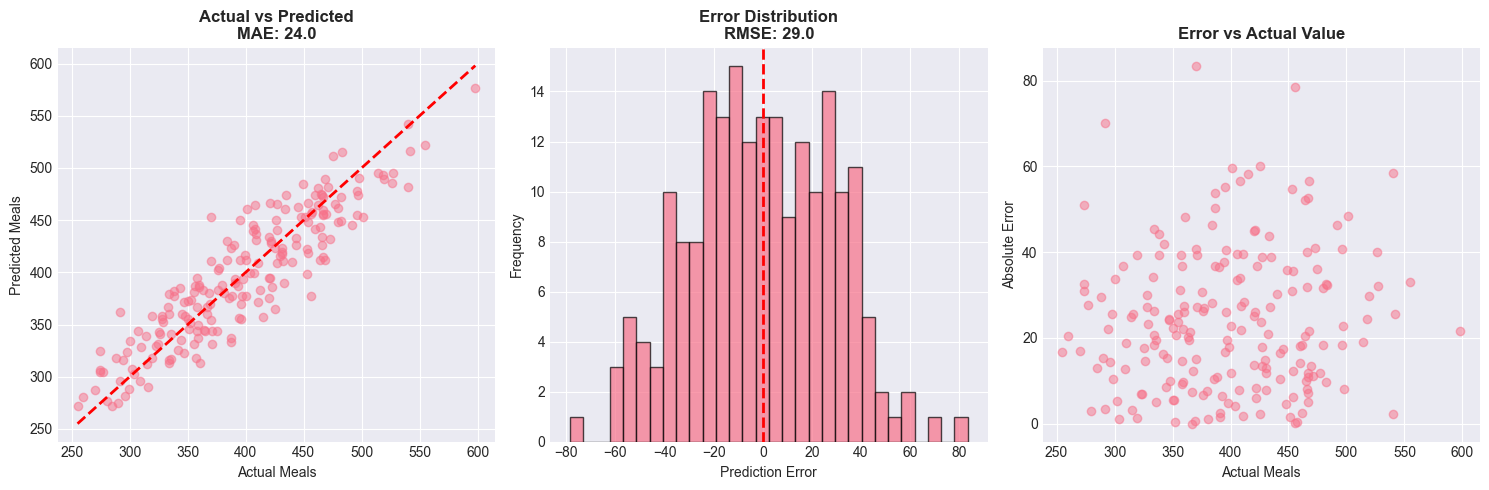


Sample Predictions (first 10 test samples):
 Actual  Predicted  Error
    421      466.0   45.0
    361      313.0   48.0
    433      389.0   44.0
    471      482.0   11.0
    365      344.0   21.0
    357      318.0   39.0
    292      295.0    3.0
    314      339.0   25.0
    430      415.0   15.0
    260      280.0   20.0

Prediction Accuracy:
   • Within ±10 meals: 23.0% of predictions
   • Within ±20 meals: 45.5% of predictions
   • Within ±30 meals: 67.0% of predictions
   • Within ±50 meals: 92.0% of predictions


In [417]:

print("COMPREHENSIVE MODEL EVALUATION")

# Get predictions for all test samples
all_predictions = best_model_fixed.predict(X_test_fixed)

# Calculate overall metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_fixed, all_predictions)
rmse = np.sqrt(mean_squared_error(y_test_fixed, all_predictions))
r2 = r2_score(y_test_fixed, all_predictions)

print(f"\nModel: {best_model_name_fixed}")
print(f"Overall Performance on Test Set ({len(y_test_fixed)} samples):")
print(f"   • Mean Absolute Error (MAE): {mae:.2f} meals")
print(f"   • Root Mean Square Error (RMSE): {rmse:.2f} meals")
print(f"   • R² Score: {r2:.3f}")

# Show prediction distribution
plt.figure(figsize=(15, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test_fixed, all_predictions, alpha=0.5)
plt.plot([y_test_fixed.min(), y_test_fixed.max()], 
         [y_test_fixed.min(), y_test_fixed.max()], 'r--', lw=2)
plt.xlabel('Actual Meals')
plt.ylabel('Predicted Meals')
plt.title(f'Actual vs Predicted\nMAE: {mae:.1f}', fontweight='bold')

# Plot 2: Error Distribution
plt.subplot(1, 3, 2)
errors = all_predictions - y_test_fixed
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title(f'Error Distribution\nRMSE: {rmse:.1f}', fontweight='bold')

# Plot 3: Error vs Actual
plt.subplot(1, 3, 3)
plt.scatter(y_test_fixed, abs(errors), alpha=0.5)
plt.xlabel('Actual Meals')
plt.ylabel('Absolute Error')
plt.title('Error vs Actual Value', fontweight='bold')

plt.tight_layout()
plt.show()

# Show sample of predictions
print("\nSample Predictions (first 10 test samples):")
results_sample = pd.DataFrame({
    'Actual': y_test_fixed.iloc[:10].values,
    'Predicted': all_predictions[:10].round(),
    'Error': abs(all_predictions[:10] - y_test_fixed.iloc[:10].values).round()
})
print(results_sample.to_string(index=False))

# Calculate what percentage of predictions are within different error ranges
within_10 = np.mean(abs(errors) <= 10) * 100
within_20 = np.mean(abs(errors) <= 20) * 100
within_30 = np.mean(abs(errors) <= 30) * 100
within_50 = np.mean(abs(errors) <= 50) * 100

print(f"\nPrediction Accuracy:")
print(f"   • Within ±10 meals: {within_10:.1f}% of predictions")
print(f"   • Within ±20 meals: {within_20:.1f}% of predictions")
print(f"   • Within ±30 meals: {within_30:.1f}% of predictions")
print(f"   • Within ±50 meals: {within_50:.1f}% of predictions")

In [418]:
# Save the final model and all necessary files
import joblib
import json

# Save model
joblib.dump(best_model_fixed, '../best_food_waste_model.pkl')

# Save feature names
feature_names = X_train_fixed.columns.tolist()
joblib.dump(feature_names, '../feature_names.pkl')

# Save model info for the Flask app
model_info = {
    'model_name': 'Linear Regression',
    'mae': 23.99,
    'rmse': 29.04,
    'r2': 0.815,
    'features': feature_names
}

with open('../model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print(" Final model saved successfully!")
print(f" Files saved in main project folder:")
print("   • best_food_waste_model.pkl")
print("   • feature_names.pkl")
print("   • model_info.json")

 Final model saved successfully!
 Files saved in main project folder:
   • best_food_waste_model.pkl
   • feature_names.pkl
   • model_info.json
